# Quantifying Orchard Resilience

Visualize sm anomalies to start with

Measure vegetation response during and after events:

Resistance = How little the NDVI dropped during stress.

Recovery = How fast NDVI bounced back after stress.

Persistence = How stable the NDVI stays over multiple years.

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns

# to pick it up fast where you left
sm_df = pd.read_csv(os.path.join('Data/soil_moisture','Soil_moisture_all.csv'), index_col=0, header=0)
sm_df.index = pd.to_datetime(sm_df.index)

print(sm_df.head())

                  sm  DOY  rolling_mean    sm_DOY  sm anomaly
time_bnds                                                    
1980-01-01       NaN    1           NaN  0.415186         NaN
1980-01-02       NaN    2           NaN  0.405549         NaN
1980-01-03  0.334001    3      0.334001  0.387955   -0.053953
1980-01-04       NaN    4      0.334001  0.395356   -0.061354
1980-01-05       NaN    5      0.334001  0.402172   -0.068171


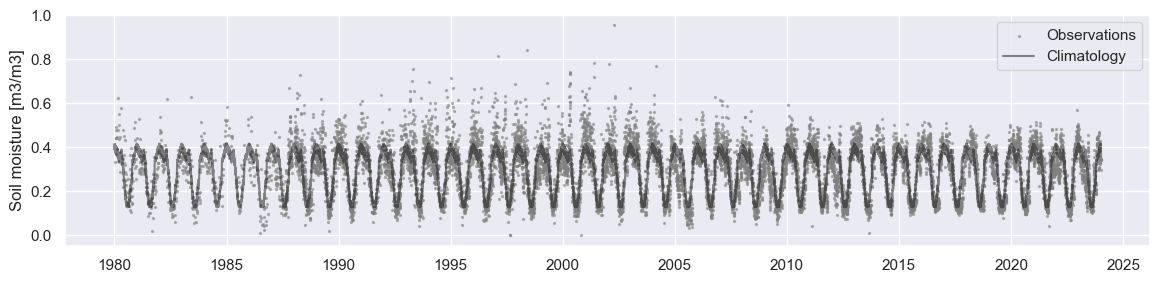

In [19]:
sns.set_theme()

fig, ax = plt.subplots(figsize=(14, 3))

plt.scatter(sm_df['sm'].index, sm_df['sm'].values, color='gray', s=2, alpha=0.5, label='Observations') 
plt.plot(sm_df['sm_DOY'].index, sm_df['sm_DOY'].values, color='k', alpha=0.5, label='Climatology')

plt.ylabel('Soil moisture [m3/m3]')
plt.legend(loc='upper right')
plt.savefig('soilmoistureALL.png', dpi=500)

plt.show()

In [42]:
# Filter dates for March to September
df_filtered = sm_df[sm_df.index.month.isin([3, 4, 5, 6, 7, 8, 9])]

# days of positive and negative anomalies and changes through years in growing season
negative_anomalies = df_filtered[(df_filtered['sm anomaly'] < 0)]
positive_anomalies = df_filtered[(df_filtered['sm anomaly'] > 0)]

# Count the number of days for each year with positive anomalies
positive_counts = positive_anomalies.groupby(positive_anomalies.index.year).size()

# Count the number of days for each year with negative anomalies
negative_counts = negative_anomalies.groupby(negative_anomalies.index.year).size()

print(positive_anomalies.head())

            sm  DOY  rolling_mean    sm_DOY  sm anomaly
time_bnds                                              
1980-03-01 NaN   61      0.480711  0.355352    0.125358
1980-03-02 NaN   62      0.480711  0.355644    0.125066
1980-03-03 NaN   63      0.408572  0.351542    0.057030
1980-03-04 NaN   64      0.477351  0.355633    0.121718
1980-03-05 NaN   65      0.477351  0.348972    0.128379


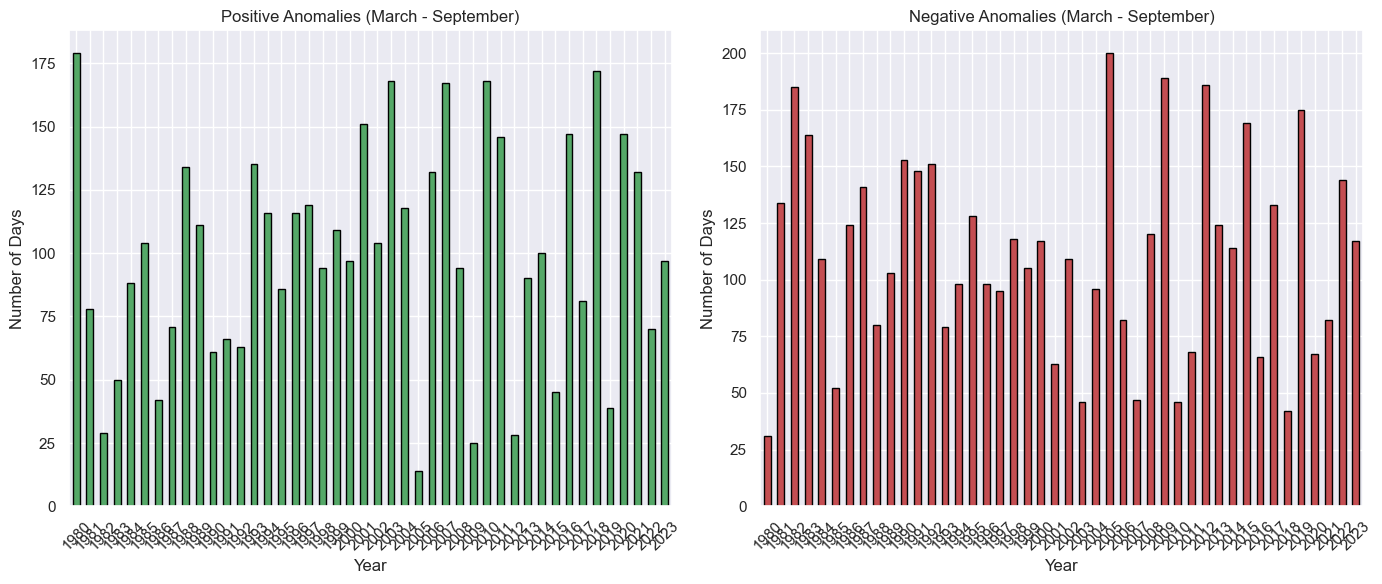

In [46]:
from scipy.stats import linregress

# Calculate summary statistics for positive anomalies
positive_mean = positive_counts.mean()
positive_std = positive_counts.std()
positive_slope, positive_intercept, positive_r_value, positive_p_value, positive_std_err = linregress(positive_counts.index, positive_counts)

# Calculate summary statistics for negative anomalies
negative_mean = negative_counts.mean()
negative_std = negative_counts.std()
negative_slope, negative_intercept, negative_r_value, negative_p_value, negative_std_err = linregress(negative_counts.index, negative_counts)

# Prepare the figure for barplots
plt.figure(figsize=(14, 6))

# Bar plot for positive anomalies
plt.subplot(1, 2, 1)
positive_counts.plot(kind='bar', color='g', edgecolor='black')
plt.title(f'Positive Anomalies (March - September)')
plt.xlabel('Year')
plt.ylabel('Number of Days')
plt.xticks(rotation=45)

# Bar plot for negative anomalies
plt.subplot(1, 2, 2)
negative_counts.plot(kind='bar', color='r', edgecolor='black')
plt.title(f'Negative Anomalies (March - September)')
plt.xlabel('Year')
plt.ylabel('Number of Days')
plt.xticks(rotation=45)

# Show plot
plt.tight_layout()
plt.show()


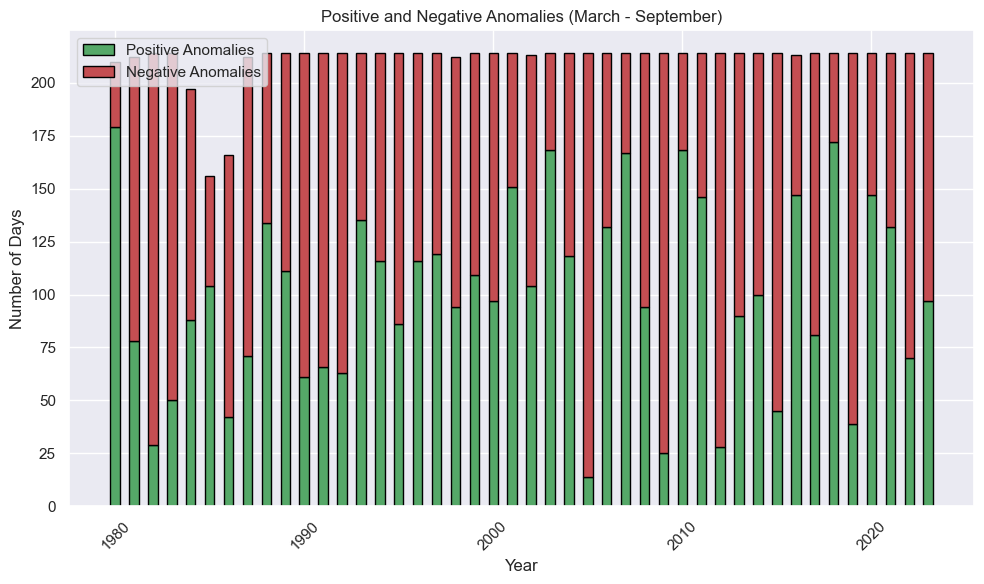

In [47]:
# Prepare the figure for the combined bar plot
plt.figure(figsize=(10, 6))

# Bar plot for both positive and negative anomalies, stacked
bar_width = 0.5  # width of the bars
plt.bar(positive_counts.index, positive_counts, width=bar_width, color='g', label='Positive Anomalies', edgecolor='black')
plt.bar(negative_counts.index, negative_counts, width=bar_width, bottom=positive_counts, color='r', label='Negative Anomalies', edgecolor='black')

# Titles and labels
plt.title(f'Positive and Negative Anomalies (March - September)')
plt.xlabel('Year')
plt.ylabel('Number of Days')
plt.xticks(rotation=45)

# Add legend
plt.legend()

# Show plot
plt.tight_layout()
plt.show()

C:\Users\ici-1\AppData\Local\Temp\ipykernel_18880\3249185491.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('bwr')  # blue-white-red


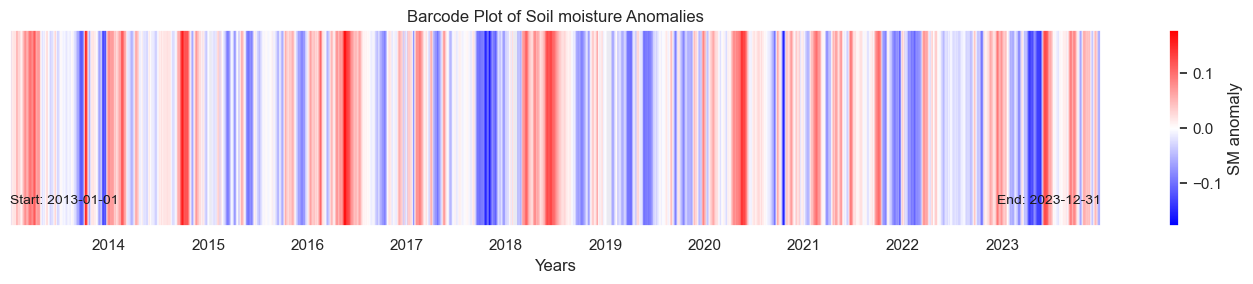

In [5]:
# Create a beautfiul plot with the downloaded data (heatmap?)
# Inspiration: https://showyourstripes.info/c/europe/portugal/lisbon
# How do I want to visualize this?

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm



# Prepare color mapping: red (-), white (0), blue (+)
norm = Normalize(vmin=sm_df['sm anomaly'].min(), vmax=sm_df['sm anomaly'].max())
cmap = cm.get_cmap('bwr')  # blue-white-red


fig, ax = plt.subplots(figsize=(14, 3))

# Create barcode plot
for i in sm_df.index:
    score = sm_df['sm anomaly'][i]
    ax.axvline(x=i, color=cmap(norm(score)), linewidth=1)


# Add start and end markers
start_label = f"Start: {sm_df.index[0].date()}"
end_label = f"End: {sm_df.index[-1].date()}"
ax.text(sm_df.index[0], 0.1, start_label, ha='left', va='bottom', fontsize=10, color='k', transform=ax.get_xaxis_transform())
ax.text(sm_df.index[-1], 0.1, end_label, ha='right', va='bottom', fontsize=10, color='k', transform=ax.get_xaxis_transform())


plt.title('Barcode Plot of Soil moisture Anomalies')
plt.yticks([])
plt.xlabel('Years')
plt.xlim(sm_df.index[0], sm_df.index[-1])


# Add colorbar with mappable
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # needed for colorbar
fig.colorbar(sm, ax=ax, orientation='vertical', label='SM anomaly')

plt.tight_layout()
plt.show()


check

There is a lot more that you can do with outputs (such as including interactive outputs)
with your book. For more information about this, see [the Jupyter Book documentation](https://jupyterbook.org)